# 3D OBJECTION CLASSIFICATION
**Authors: Noemi Stefani (2095639) and Marco Minchella (2131787 / 2159400).**
<br> <br> The purpose of the project is to be able to classify objects in 3D using a Neural Network trained from ModelNet10 and ModelNet40 data.
In this code we present four convolutional neural networks, ORION1 which is implementation of the original ORION on which we based and ORION2, ORION3 and ORION4 have undergone modifications to study the accuracy of the model.

# CLASSIFICATION WITH ORION
1. **Importing libraries**: *torch* for PyTorch, *wandb* for monitoring training, *numpy* for numerical manipulations, and *os* for setting environment variables.


In [1]:
!pip install wandb

import torch
import wandb
import numpy as np
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.8/325.8 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 904.1 kB/s eta 0:00:00


2. **Create Voxelgrid:** Used to represent 3D geometric shapes as a probability distribution of binary variables on a 3D Voxel grid.
This class is responsible for reading a text file that contains paths to .h5 (HDF5) files.
Load voxel data, labels (labels) and poses from each HDF5 file then combine data from multiple files into a single array and finally provide a method of accessing the elements of the dataset, which can be used with a DataLoader.


In [2]:
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
import os

class MyVoxelDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels=None):
        # Read the text file with the paths to .h5 files
        with open(data) as file:
            lines = file.readlines()

        # Define the directory to the file
        base_dir = "/content/drive/MyDrive/datasets/"

        # Create a list of paths
        self.paths = [os.path.join(base_dir, line.strip('\n').replace('../../datasets', '').lstrip('/')) for line in lines]

        # Combine all the file .h5 in the correct data arrays, labels and poses
        self.data, self.label, self.label_pose = self._combine_files()

        # Verify that self.data has been loaded correctly.
        print(f"Number of samples loaded into self.data: {len(self.data)}")  # Debug

    def _combine_files(self):
        combined_data = []
        combined_label = []
        combined_label_pose = []

        for path in self.paths:
            print(f"Open the file: {path}")
            try:
                with h5py.File(path, 'r') as file:
                    # Extract voxel data, labels and poses.
                    data = file['data'][:]  # [:] To get all data
                    label = np.int64(file['label'][:])  # [:] To extract the array
                    label_pose = np.int64(file['label_pose'][:])

                    # Add extracted data to combined lists
                    combined_data.append(data)
                    combined_label.append(label)
                    combined_label_pose.append(label_pose)
                    print(f"File {path} successfully uploaded.")  # Debug: loaded file
            except Exception as e:
                print(f"Error to open the file {path}: {e}")

        # Concatenation only if there is data
        combined_data = np.concatenate(combined_data, axis=0) if combined_data else np.array([])
        combined_label = np.concatenate(combined_label, axis=0) if combined_label else np.array([])
        combined_label_pose = np.concatenate(combined_label_pose, axis=0) if combined_label_pose else np.array([])

        return combined_data, combined_label, combined_label_pose

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data = self.data[idx]
        label = self.label[idx]
        label_pose = self.label_pose[idx]
        return data, label, label_pose



3. **Transformations**:
- CropTransform: This class is used to crop the voxel data. It takes a central portion of the voxel grid from a size of 36x36x36 to a size of 32x32x32, removing 2 voxels along each axis. This reduces the size of the data evenly.

- ToTensor: Converts voxel data to a PyTorch tensor (necessary because PyTorch works with tensors, not NumPy arrays). Also, the data is converted to float32.

- Compose: This function of the torchvision.transforms library allows multiple transformations to be applied sequentially, in this case clipping (CropTransform) and conversion to tensor (ToTensor).


In [3]:
from torchvision.transforms import Compose

class CropTransform(torch.nn.Module):
    def forward(self, data):
        # Cut the Voxel data in 32x32x32
        cropped_data = data[:, 2:34, 2:34, 2:34]
        return cropped_data

class ToTensor(torch.nn.Module):
    def forward(self, data):
        # Converts to PyTorch tensor
        tensor = torch.from_numpy(data.astype(np.float32))
        return tensor

# Create the transformation pipeline
transforms = Compose([
    CropTransform(),
    ToTensor()
])


4. **Dataset Selection**: The code allows selection of the dataset to be used (ModelNet10 or ModelNet40) and the number of rotations to be applied.


In [4]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [5]:
# Select the dataset we want to use by pasting the correct directory path

train_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.txt',transforms)
#train_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet40_bin_from_mat/poseplan_MN40/hdf5/train/train.txt',transforms)
validation_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/validation/validation.txt', transforms)
#validation_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet40_bin_from_mat/poseplan_MN40/hdf5/validation/validation.txt', transforms)
test_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/test/test.txt', transforms)
#test_dataset = MyVoxelDataset(f'/content/drive/MyDrive/datasets/ModelNet40_bin_from_mat/poseplan_MN40/hdf5/test/test.txt', transforms)

# dataloaders
train_dataloader = DataLoader(train_dataset,32, shuffle=True, num_workers=0)
validation_dataloader = DataLoader(validation_dataset,12, shuffle=False, num_workers=0)
test_dataloader = DataLoader(test_dataset,12, shuffle=False, num_workers=0)

Open the file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5 successfully uploaded.
Open the file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5.0002
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5.0002 successfully uploaded.
Open the file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5.0003
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5.0003 successfully uploaded.
Open the file: /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5.0004
File /content/drive/MyDrive/datasets/ModelNet10_bin_from_mat/poseplan_MN10/hdf5/train/train.hdf5.0004 successfully uploaded.
Open the file: /content/drive/MyDrive/datasets/ModelNet10_bin_

5. **Data visualization**

To better understand the data discussed we want to bring examples of visualization. In the first case we see the histogram of the distribution of samples in classes. In the other two we have a 2D representation with z-axis fixed and 3D representation of the chosen object

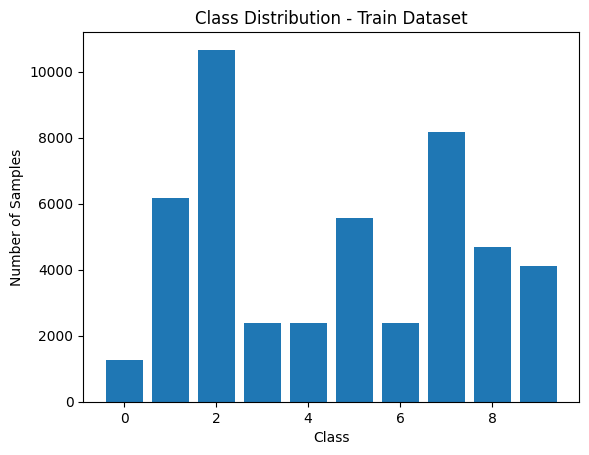

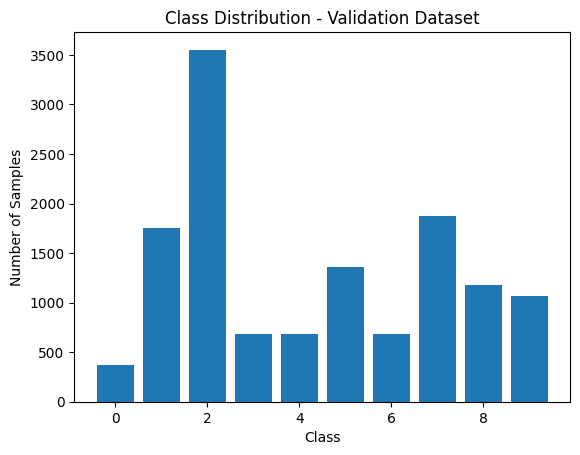

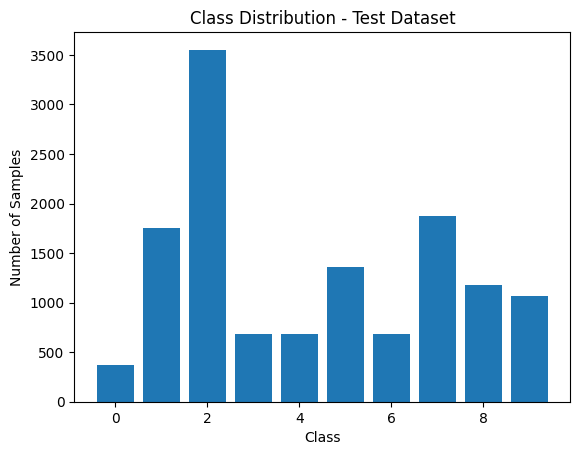

In [ ]:
import matplotlib.pyplot as plt

# Train dataset
unique_labels, counts = np.unique(train_dataset.label, return_counts=True)

# Graph
plt.bar(unique_labels, counts)
plt.title('Class Distribution - Train Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

# Validation dataset
unique_labels, counts = np.unique(validation_dataset.label, return_counts=True)

# Graph
plt.bar(unique_labels, counts)
plt.title('Class Distribution - Validation Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

# Test dataset
unique_labels, counts = np.unique(validation_dataset.label, return_counts=True)

# Graph
plt.bar(unique_labels, counts)
plt.title('Class Distribution - Test Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()


Content of the 'date' object (form): (1000, 1, 36, 36, 36)
Number of nonzero voxels: 1792975 out of 46656000 total.
I dati sembrano essere binari.


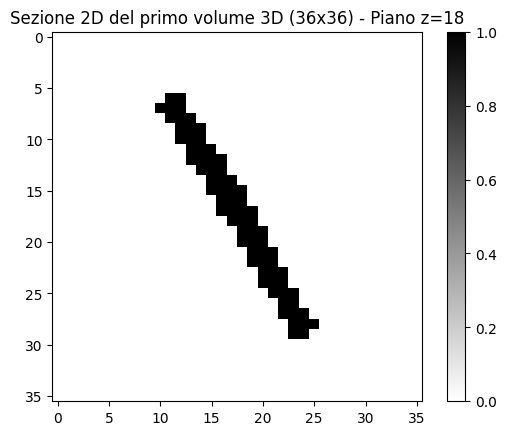

In [ ]:
import numpy as np
import h5py

def read_hdf5_data(file_path):
    try:
        with h5py.File(file_path, 'r') as f:
            if 'data' in f:
                data = f['data'][:]
                print(f"Content of the 'date' object (form): {data.shape}")
                return data
            else:
                print("'data' is not find.")
                return None
    except Exception as e:
        print(f"Error opening file {file_path}: {e}")

# File path
file_path = '/content/drive/MyDrive/datasets/ModelNet40_bin_from_mat/poseplan_MN40/hdf5/train/train.hdf5.0051'

# Read and view data
data = read_hdf5_data(file_path);


def analyze_voxel_data(data):
    non_zero_voxels = np.count_nonzero(data)
    total_voxels = np.prod(data.shape)
    print(f"Number of nonzero voxels: {non_zero_voxels} out of {total_voxels} total.")

    # Check whether the data are binary (all zeros or ones)
    if np.all((data == 0) | (data == 1)):
        print("The data appear to be binary.")
    else:
        print("The data do not appear to be binary.")

# Review data
if data is not None:
    analyze_voxel_data(data)
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


# Display a 2D section of the first volume.
# For example, we take the middle plane along the z-axis (index 18).
plt.imshow(data[0, 0, 18, :, :], cmap='binary')
plt.title("2D section of the first 3D volume (36x36) - plane z=18")
plt.colorbar()
plt.show()


We show the data in 3D as well

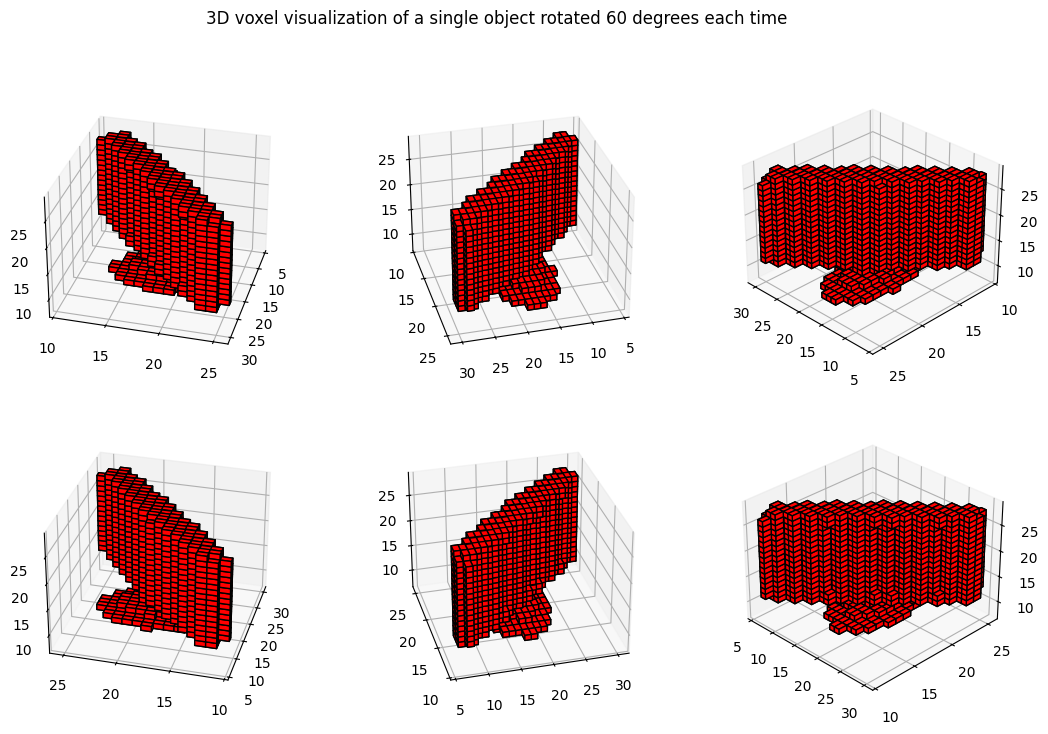

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'data' is your voxel data (numpy array)
# Example: data = read_hdf5_data(file_path)

# View data 3D
if data is not None:
    # Choose a single voxel grid to visualize
    voxel_grid = data[0, 0]
    fig = plt.figure(figsize=(13, 8))

    for i in range(1,7):
      # Create the 3D plot
      ax = fig.add_subplot(2,3,i, projection='3d')

      # Use voxels function to plot the voxel grid
      ax.voxels(voxel_grid,facecolor='red', edgecolor='k')

      ax.view_init(30, -45+60*i, vertical_axis='x')  # Adjust elevation and azimuth angles as needed (six 60 degrees rotations)



    fig.suptitle('3D voxel visualization of a single object rotated 60 degrees each time')
    plt.show()

else:
    print("Data is not loaded correctly. Please verify the data.")

# NEURAL NETWORK
The proposed model is designed to address two main tasks: object classification and pose estimation. Its architecture combines a 3D convolutional network for feature extraction and a fully connected section to produce the two outputs.

## ORION1

Convolutional Network:
- The network includes 4 three-dimensional convolutional layers (Conv3D), each followed by:
    - Batch Normalization, to stabilize activations and improve convergence.
    - ReLU as an activation function, chosen for its simplicity and effectiveness.
    - Dropout3d, with a progressively increasing probability (from 0.2 to 0.6) to reduce the risk of overfitting.
    
- The fourth and final convolutional layer is followed by a 3D MaxPooling operation, which reduces spatial dimensionality, allowing the model to focus on the most relevant features.

Fully Connected part:
- The output of the convolutional network is flattened and passed through an intermediate fully connected layer (fc1), consisting of:
    - 128 neurons, with a latent representation serving as the basis for the outputs.
    - ReLU to introduce nonlinearity.
    - Dropout with a probability of 0.4 for regularization.
- The network is then divided into two distinct outputs:
    - Classification (class_output): a linear layer that returns the prediction of the class of the object.
    - Pose estimation (pose_output): a linear layer that returns the prediction of the orientation.

Initialization of Weights
- The weights of the convolutional network are initialized with the Kaiming Normal technique, which is ideal for layers with a ReLU activation function because it keeps the variance of the gradients stable in the convolutional layers.
- The weights of fully connected layers are initialized with a normal distribution with standard deviation of 0.01, while the biases are initialized to zero in all layers.

The proposed model is the implementation of the ORION network on which we based our project.


In [6]:
import torch.nn as nn
from torch.nn import Module, Sequential, Conv3d, BatchNorm3d, ReLU, Dropout3d, MaxPool3d, Linear, LeakyReLU, Dropout
# Model class
class ORION1(Module):

    # Model initialization
    def __init__(self, num_classes, num_pose_label):
        super().__init__()

        # Convolutional network with 4 convolutional layers, BatchNorm, ReLU and Dropout
        self.network = Sequential(

          # Layer 1: Conv3D, BatchNorm3d, ReLU, Dropout3d (p=0.2)
          Conv3d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
          BatchNorm3d(num_features=32),
          ReLU(),
          Dropout3d(p=0.2),

          # Layer 2: Conv3D, BatchNorm3d, ReLU, Dropout3d (p=0.3)
          Conv3d(in_channels=32, out_channels=64, kernel_size=3, stride=1),
          BatchNorm3d(num_features=64),
          ReLU(),
          Dropout3d(p=0.3),

          # Layer 3: Conv3D, BatchNorm3d, ReLU, Dropout3d (p=0.4)
          Conv3d(in_channels=64, out_channels=128, kernel_size=3, stride=1),
          BatchNorm3d(num_features=128),
          ReLU(),
          Dropout3d(p=0.4),

          # Layer 4: Conv3D, BatchNorm3d, ReLU, MaxPool3d, Dropout3d (p=0.6)
          Conv3d(in_channels=128, out_channels=256, kernel_size=3, stride=1),
          BatchNorm3d(num_features=256),
          ReLU(),
          MaxPool3d(kernel_size=2),
          Dropout3d(p=0.6),
        )
        # Fully connected layer with 128 neurons, ReLU and Dropout (p=0.4)
        self.fc1 = Sequential(
            Linear(in_features=256*4*4*4, out_features=128),
            ReLU(),
            Dropout(p=0.4)
        )
        # Class classification layer
        self.class_layer = Linear(in_features=128, out_features=num_classes)
        # Pose classification layer
        self.pose_layer = Linear(in_features=128, out_features=num_pose_label)
        # Custom weights initialization
        self.apply(self._init_weights)

    # Forward pass
    def forward(self, x):

        # Pass the input through the convolutional network.
        # Flatten (flatten) the output to pass it to the fully connected layer.
        x =  self.network(x).reshape((x.shape[0],-1))
        # Step through the first level fully connected (fc1).
        x = self.fc1(x)
        # Return the classification output and the pose.
        class_output = self.class_layer(x)
        pose_output = self.pose_layer(x)
        return class_output, pose_output

    # Define the method for initializing the weights (_init_weights).
    def _init_weights(self, module):
        # Initialize the weights for fully connected (Linear) layers using the normal distribution.
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.normal_(module.weight, std=0.01)
            if module.bias is not None:
                module.bias.data.zero_()
        # Initialize weights for convolutional layers (Conv3d) using Kaiming initialization.
        if isinstance(module, torch.nn.Conv3d):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                module.bias.data.zero_()

## ORION2
This new neural network keeps all the structure present in ORION1 unchanged, but ELU and Tanh are used as activation functions in order to be able to analyze the change in accuracy.


In [7]:
import torch
from torch import optim
from torch.nn import Module, Sequential, Conv3d, BatchNorm3d, Tanh, ELU, Dropout3d, MaxPool3d, Linear, Dropout

# Model class
class ORION2(Module):

    # Define the initialization of the model
    def __init__(self, num_classes, num_pose_label, activation):
        super(ORION2, self).__init__()

        # Select the activation function (Tanh or ELU).
        if activation == 'tanh':
            activation_fn = Tanh()
        elif activation == 'elu':
            activation_fn = ELU()
        else:
            raise ValueError("Activation function not supported. Use 'tanh' or 'elu'.")

        # Define the convolutional network with 4 convolutional layers, BatchNorm and Dropout.
        self.network = Sequential(
            Conv3d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
            BatchNorm3d(num_features=32),
            activation_fn,
            Dropout3d(p=0.2),

            Conv3d(in_channels=32, out_channels=64, kernel_size=3, stride=1),
            BatchNorm3d(num_features=64),
            activation_fn,
            Dropout3d(p=0.3),

            Conv3d(in_channels=64, out_channels=128, kernel_size=3, stride=1),
            BatchNorm3d(num_features=128),
            activation_fn,
            Dropout3d(p=0.4),

            Conv3d(in_channels=128, out_channels=256, kernel_size=3, stride=1),
            BatchNorm3d(num_features=256),
            activation_fn,
            MaxPool3d(kernel_size=2),
            Dropout3d(p=0.6),
        )
        # Fully connected layer with 128 neurons, custom activation and Dropout (p=0.4)
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=32000, out_features=128),
            activation_fn,
            Dropout(p=0.4)
        )

        # Layer grading and pose estimation
        self.class_layer = Linear(in_features=128, out_features=num_classes)
        self.pose_layer = Linear(in_features=128, out_features=num_pose_label)

        # Custom weight initialization.
        self.apply(self._init_weights)

    # Forward method for forward passage in the network.
    def forward(self, x):
        x = self.network(x).reshape((x.shape[0], -1))
        x = self.fc1(x)
        class_output = self.class_layer(x)
        pose_output = self.pose_layer(x)
        return class_output, pose_output

    # Initialization of weights
    def _init_weights(self, module):
        if isinstance(module, Linear):
            torch.nn.init.normal_(module.weight, std=0.01)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, Conv3d):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                module.bias.data.zero_()


**Optimization functions:** we want to compare the results using two different optimizers, adam and rmsprop.

In [8]:
def get_optimizer(model, optimizer_type, lr):
    if optimizer_type == 'adam':
        return optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'rmsprop':
        return optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Activation function not supported. Use 'adam' or 'rmsprop'.")

# TRAINING AND TEST
The purpose of the `calculate_accuracies` function is to calculate essential evaluation metrics for a series of tests.  Predictions are obtained by summing the rotations to identify the class, then applying **softmax** to derive the pose. In addition to accuracy, metrics such as **precision**, **recall** and **F1-score** are also calculated for a more comprehensive evaluation of the model. Finally, the predictions and corresponding labels are saved in a CSV file for further analysis.

The function is structured as follows:

1. **Device Setup**: The model is moved to the CPU (in this case, CUDA is not used).

2. **Softmax**: The softmax function is established to calculate the probabilities of the predicted poses.

3. Mode **Eval()**: The model enters evaluation mode (`eval()`), which prevents gradient calculation and back-propagation.

4. **Batch processing**: Each batch of data is transferred and converted to the appropriate type before being processed by the model.

5. **Predictions and calculations**:

   - **Classification**: Rotation predictions are summed (as each batch contains rotations of the same object) to determine the predicted class, using `torch.argmax` to find the class with the highest probability.

   - **Pose**: The pose prediction undergoes softmax processing, followed by `torch.argmax` to finalize the pose.

6. **Saving of predictions**: The class and pose predictions, along with the actual labels, are accumulated in separate arrays.

7. **Calculation of metrics**: At the end, the accuracies for class and pose are calculated and returned as results.

So the function will return:
- **class_accuracy**: The accuracy in class prediction.
- **pose_accuracy**: The accuracy in the prediction of poses.

This approach allows for a more thorough evaluation of the model's performance, taking into account not only the accuracy of class predictions, but also the accuracy of pose estimation, which is essential for applying the model.

In [9]:
from tqdm import tqdm
def calculate_accuracies (network, dataloader):
    device = "cpu"
    network.to(device)

    softmax= torch.nn.Softmax(dim=1)

    network.eval()
    # Calculate test accuracy
    iterator = tqdm(dataloader, disable=True)
    with torch.no_grad():
        class_pred_arr = []
        class_true_arr = []
        pose_pred_arr = []
        pose_true_arr = []

        for batch_data, batch_class_labels, batch_pose_labels in iterator:

            batch_data = batch_data.to(device)
            batch_data = batch_data.type(torch.float32)
            batch_class_labels = batch_class_labels.squeeze().to(device)
            batch_pose_labels = batch_pose_labels.squeeze().to(device)

            # Ensure labels are integers and within the valid range
            batch_class_labels = batch_class_labels.type(torch.long)
            batch_pose_labels = batch_pose_labels.type(torch.long)

            batch_class_labels = torch.clamp(batch_class_labels, 0, num_classes - 1)
            batch_pose_labels = torch.clamp(batch_pose_labels, 0, num_poses - 1)

            # Forward pass
            class_pred, pose_pred = network(batch_data)

            # Converting to pose_label
            pose_pred = softmax(pose_pred)
            pose_pred = torch.argmax(pose_pred, dim=1)

            # Converting class output to single prediction
            sum_class_pred = torch.sum(class_pred, dim=0)
            class_pred = torch.argmax(sum_class_pred)

            # Taking the firt elements (of the 12 orientations the first is the true class)
            batch_class_labels = batch_class_labels[0]

            # Labels and predictions
            class_pred_arr.append(class_pred)
            class_true_arr.append(batch_class_labels)
            pose_pred_arr.append(pose_pred)
            pose_true_arr.append(batch_pose_labels)

        # Concatenating
        class_pred_arr = torch.stack(class_pred_arr)
        class_true_arr = torch.stack(class_true_arr)
        pose_pred_arr = torch.cat(pose_pred_arr, axis=0)
        pose_true_arr = torch.cat(pose_true_arr, axis=0)

        # Calculating accuracies
        class_accuracy = torch.sum(class_pred_arr == class_true_arr)/len(class_true_arr)
        pose_accuracy = torch.sum(pose_pred_arr == pose_true_arr)/len(pose_true_arr)

        return class_accuracy, pose_accuracy

The purpose of the `calculate_loss` function is to calculate the loss on the validation and test sets, helping to provide more accurate evaluation and continuous assessment of model performance. Monitoring the loss during validation is essential to detect potential problems such as **overfitting** or **underfitting** during the training process. In particular, monitoring leakage can facilitate the implementation of strategies such as **early stop**, which stops training when leakage ceases to improve, thus preventing overtraining and improving the generalization capabilities of the model.

The `calculate_loss` function is structured as follows:

1. **Device Setup**: The model is moved to the **CPU** since CUDA is not available in this context.

2. **Loss functions**: Two **CrossEntropyLoss** functions are created, one for classification tasks and the other for pose estimation.

3. **Evaluation Mode**: The model is switched to **eval()** mode to avoid gradient computation, which helps minimize memory usage during inference.

4. **Data processing**:
    - Batches of data are sent to the CPU and formatted appropriately for the model.
    - The labels are converted to the **long** type and checked to make sure they are within the valid range.

5. **Predictions**: The model generates predictions for each batch, producing results for both grading and laying.

6. **Loss Calculation**:
    - The loss for classification and the loss for laying are computed separately using the **CrossEntropyLoss** function.
    - The overall loss is then calculated by averaging the two.

7. **Return of results**: The function outputs the **totalloss**, the **gradingloss**, and the **layingloss**.

This function is beneficial for observing the model's performance on validation and test data, making it simpler to detect any training issues and enhancing the model's generalization ability.

In [10]:
from torch.nn import CrossEntropyLoss

def calculate_loss (network, dataloader):

    device = "cpu"
    network.to(device)

    # Loss functions (we use cross entropy)
    loss_fn_class = CrossEntropyLoss()
    loss_fn_pose = CrossEntropyLoss()

    network.eval()
    iterator = tqdm(dataloader, disable=True)

    # stopping calculating gradients and forward pass
    with torch.no_grad():
        class_pred = []
        class_true = []
        pose_pred = []
        pose_true = []

        # Cycle through the batches
        for batch_data, batch_class_labels, batch_pose_labels in iterator:

            batch_data = batch_data.to(device)
            batch_data = batch_data.type(torch.float32)
            batch_class_labels = batch_class_labels.squeeze().to(device)
            batch_pose_labels = batch_pose_labels.squeeze().to(device)

            # Ensure labels are integers and within the valid range
            batch_class_labels = batch_class_labels.type(torch.long)
            batch_pose_labels = batch_pose_labels.type(torch.long)

            batch_class_labels = torch.clamp(batch_class_labels, 0, num_classes - 1)
            batch_pose_labels = torch.clamp(batch_pose_labels, 0, num_poses - 1)

            # Forward pass
            out_class_pred, out_pose_pred = network(batch_data)

            # Adding labels and prediction
            class_pred.append(out_class_pred)
            class_true.append(batch_class_labels)
            pose_pred.append(out_pose_pred)
            pose_true.append(batch_pose_labels)

        # Get a single tensor
        class_pred = torch.cat(class_pred, axis=0)
        class_true = torch.cat(class_true, axis=0)
        pose_pred = torch.cat(pose_pred, axis=0)
        pose_true = torch.cat(pose_true, axis=0)

        # Loss calculation (we do the average of the pose and class losses)
        class_loss = loss_fn_class(class_pred, class_true)
        pose_loss = loss_fn_pose(pose_pred, pose_true)
        loss = (class_loss + pose_loss)/2

    return loss, class_loss, pose_loss


The `training_epoch` function is responsible for training the model during each epoch. Initially, the neural network is set to **"train ”** mode via `network.train()`, enabling the calculation and recording of gradients needed to update the weights during the **backpropagation** process.

The workflow includes the following steps:

1. **Training Mode**: The network is put into `train' mode, which enables gradient calculation and optimization during the epoch.
2. **Iteration on Data**: An iterator is created on the **dataloader** to run through the data batch by batch.
3. **Pre-processing of Data**:
   - Batch data is transferred to the **CPU** (since CUDA is not supported here).
   - Class and pose labels are prepared and adapted to the required format, ensuring that they are **long** values and within the valid range.
   - If the class or pose labels are blank, the batch is skipped.
4. **Forward Pass**: The batch is passed through the neural network to obtain the predictions for class (`class_pred`) and pose (`pose_pred`).
5. **Calculation of Loss**:
   - Classification **loss** is calculated by comparing class predictions with actual labels, using the **CrossEntropyLoss** function.
   - The **loss of pose** is calculated in the same way, using another function of **CrossEntropyLoss** for pose.
   - The **total **loss** is the average of the two losses (grading and laying).
6. **Log of Metrics**: The values of the **totalloss**, **classificationloss** and **layingloss** are logged via `wandb.log()` to monitor the training progress in real time.
7. **Backward Pass and Optimization**:
   - Gradients are set to zero via `optimizer.zero_grad()`.
   - The **backpropagation** is performed via `train_loss.backward()`, computing the gradients with respect to the model weights.
   - Optimization of the weights is done by `optimizer.step()`, which updates the model weights based on the calculated gradients.
8. **Display of Results**: During iteration, the iterator descriptor (`iterator.set_description`) is updated, showing the **train loss**, **class loss** and **pose loss** for each batch.

In this way, the function allows detailed monitoring of training, providing useful information to diagnose any problems such as **overfitting** or **underfitting**. In addition, saving metrics makes it possible to analyze training progress and improve model generalization.



In [11]:
def training_epoch(dataloader, network, loss_fn_class, loss_fn_pose, optimizer):

    device = "cpu"
    # Network in training mode
    network.train()
    iterator = tqdm(dataloader)

    for batch_data, batch_class_labels, batch_pose_labels in iterator:
        # Check if batch_class_labels and batch_pose_labels are empty
        if batch_class_labels.nelement() == 0 or batch_pose_labels.nelement() == 0:
            # Skip this batch if either label is empty
            print("Skipping batch due to empty labels.")

        batch_data = batch_data.to(device)
        batch_data = batch_data.type(torch.float32)
        batch_class_labels = batch_class_labels.squeeze().to(device)
        batch_pose_labels = batch_pose_labels.squeeze().to(device)


        batch_class_labels = batch_class_labels.type(torch.long)
        batch_pose_labels = batch_pose_labels.type(torch.long)

        batch_class_labels = torch.clamp(batch_class_labels, 0, num_classes - 1)
        batch_pose_labels = torch.clamp(batch_pose_labels, 0, num_poses - 1)

        # Forward pass
        class_pred, pose_pred = network(batch_data)

        # Debug: Check for NaNs and Infs in predictions and labels
        if torch.isnan(class_pred).any() or torch.isinf(class_pred).any():
            print("NaN or Inf detected in class_pred!")
            import pdb; pdb.set_trace()  # Enter debugging mode
        if torch.isnan(pose_pred).any() or torch.isinf(pose_pred).any():
            print("NaN or Inf detected in pose_pred!")
            import pdb; pdb.set_trace()  # Enter debugging mode
        if torch.isnan(batch_class_labels).any() or torch.isinf(batch_class_labels).any():
            print("NaN or Inf detected in batch_class_labels!")
            import pdb; pdb.set_trace()  # Enter debugging mode

        # Losses calculation
        class_loss = loss_fn_class(class_pred, batch_class_labels)
        pose_loss = loss_fn_pose(pose_pred, batch_pose_labels)
        train_loss = (class_loss + pose_loss)/2
        wandb.log({"train_loss": train_loss, "pose_train_loss": pose_loss, "class_train_loss": class_loss })

        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # Batch results
        iterator.set_description(f"Train loss: {train_loss.detach().cpu().numpy()} class loss: {class_loss.detach().cpu().numpy()}  pose loss: {pose_loss.detach().cpu().numpy()}")

Defining two functions for checkpointing in order to resume training in case of unexpected stops

In [12]:
def checkpoint(model,optimizer, filename):
    torch.save({
       'optimizer': optimizer.state_dict(),
       'model': model.state_dict(),
    }, filename)

def resume(model,optimizer, filename):
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])

We define the `training_loop` function, which is responsible for training the network weights. This function invokes other methods to perform training and validation steps, monitor performance metrics, and manage model checkpoints. It also implements early stopping to prevent overfitting and records the training progress using wandb.




In [13]:
def training_loop(network, optimizer, train_dl, val_dl, test_dl, epochs, early_stopping, start_epoch, folder_number):

    loss_fn_class = CrossEntropyLoss()
    loss_fn_pose = CrossEntropyLoss()

    device = "cpu"
    network.to(device)

    best_val_loss = np.inf
    es_count = 0 #early stopping counter

    # iterating through the epochs
    for epoch in range(start_epoch, epochs):
        print('\nEpoch: '+str(epoch))

        # TRAINING
        print("TRAINING PHASE")

        # Call train functuon
        training_epoch(train_dl, network, loss_fn_class, loss_fn_pose, optimizer)

        # VALIDATION
        print("VALIDATION PHASE")

        # Losses calculation on validation set
        val_loss, val_class_loss, val_pose_loss = calculate_loss(network, val_dl)

        # Accuracies calculation on validation set
        val_class_acc, val_pose_acc  = calculate_accuracies(network, val_dl)

        # Log results
        wandb.log({"epoch": epoch,
                "validation_loss": val_loss,
                "pose_validation_loss": val_pose_loss,
                "class_validation_loss": val_class_loss,
                "class_validation_accuracy": val_class_acc,
                "pose_validation_accuracy": val_pose_acc,
                "class_validation_error": 1-val_class_acc,
                "pose_validation_error": 1-val_pose_acc})


        # View results
        print(f"Validation loss: {val_loss.detach().cpu().numpy()} \n class loss: {val_class_loss.detach().cpu().numpy()} \n pose loss: {val_pose_loss.detach().cpu().numpy()} \n class accuracy: {val_class_acc.detach().cpu().numpy()} \n pose accuracy: {val_pose_acc.detach().cpu().numpy()}")

        # Update and save
        if val_loss < best_val_loss:
            print("Saved Model")
            torch.save(network.state_dict(), "model.pt")
            torch.save(network.state_dict(), f"/content/drive/MyDrive/model_best.pt")
            best_val_loss = val_loss
            es_count = 0
        else:
            # Early stopping counter incrementation
            es_count += 1

        #Early stopping condition
        if es_count >= early_stopping :
            print("Early stopping")
            wandb.finish()
            break

        checkpoint(network,optimizer, f"/content/drive/MyDrive/SavedEpochs_{folder_number}/epoch-{epoch}.pth")

# MODELNET 10
In this section we will train and analyze activation functions on the ModelNet10 dataset. For each activation function we will use both optimizers in order to obtain a more complete and in-depth comparison. So we get four possible combinations and to compare.

## *ELU-ADAM*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_3"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",

    config={
    "dataset": "ModelNet10",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: e-annacosta (e-annacosta-universidad-de-granada) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [ ]:
# Initialization
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 10
num_poses = last_pose_label[0]+1

# Stopping criterion
max_epochs = 200
early_stopping = 10
start_epoch = 0
resume_epoch = 0
folder_number = 3



model = ORION2(num_classes, num_poses,'elu')
opt = get_optimizer(model,'adam',lr=1e-5)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()


Epoch: 0
TRAINING PHASE


Train loss: 2.1312496662139893 class loss: 0.9862428903579712  pose loss: 3.276256561279297: 100%|██████████| 1497/1497 [07:12<00:00,  3.46it/s]


VALIDATION PHASE
Validation loss: 1.9929560422897339 
 class loss: 0.8721655011177063 
 pose loss: 3.1137466430664062 
 class accuracy: 0.7427272796630859 
 pose accuracy: 0.40310606360435486
Saved Model

Epoch: 1
TRAINING PHASE


Train loss: 1.894457459449768 class loss: 1.0012078285217285  pose loss: 2.7877070903778076: 100%|██████████| 1497/1497 [07:38<00:00,  3.27it/s]


VALIDATION PHASE
Validation loss: 1.2543065547943115 
 class loss: 0.6436049938201904 
 pose loss: 1.865007996559143 
 class accuracy: 0.8054545521736145 
 pose accuracy: 0.6446969509124756
Saved Model

Epoch: 2
TRAINING PHASE


...

Train loss: 0.21323832869529724 class loss: 0.11005677282810211  pose loss: 0.3164198696613312: 100%|██████████| 1497/1497 [07:43<00:00,  3.23it/s]


VALIDATION PHASE
Validation loss: 0.16457530856132507 
 class loss: 0.09983619302511215 
 pose loss: 0.2293144315481186 
 class accuracy: 0.9736363887786865 
 pose accuracy: 0.9163636565208435
Saved Model

Epoch: 87
TRAINING PHASE


Train loss: 0.11391293257474899 class loss: 0.027727827429771423  pose loss: 0.20009803771972656: 100%|██████████| 1497/1497 [07:39<00:00,  3.26it/s]


VALIDATION PHASE


KeyboardInterrupt: 

In [ ]:
#Show validation and test accuracies
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

<ipython-input-19-5eb8e5b6031f>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pt"))


Validation Class Accuracy : tensor(0.9736)
Validation Pose Accuracy : tensor(0.9164)
Test Class Accuracy : tensor(0.9254)
Test Pose Accuracy : tensor(0.8489)


## *TANH-ADAM*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_4"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",

    config={
    "dataset": "ModelNet10",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
# Initialization parameters
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 10
num_poses = last_pose_label[0]+1  # +1 to include also zero label
# Selecting stopping criterion
max_epochs = 200
early_stopping = 10
start_epoch = 174
resume_epoch = 0
folder_number = 4



model = ORION2(num_classes, num_poses,'tanh')
opt = get_optimizer(model,'adam',lr=1e-5)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"/content/drive/MyDrive/SavedEpochs_4/epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)


In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

## *ELU-RMSPROP*



In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_5"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",
    name = "MN10-RMSprop-Relu",

    config={
    "dataset": "ModelNet10",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
#Initialization parameters
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 10
num_poses = last_pose_label[0]+1  # +1 to include also zero label
# Selecting stopping criterion
max_epochs = 200
early_stopping = 7
start_epoch = 0
resume_epoch = 0
folder_number = 5



model = ORION2(num_classes, num_poses,'elu')
opt = get_optimizer(model,'rmsprop',lr=1e-5)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"/content/drive/MyDrive/SavedEpochs_5/epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

## *TANH-RMSPROP*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_6"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",
    name = "MN10-RMSprop-Tanh",

    config={
    "dataset": "ModelNet10",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
# Initialization parameters
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 10
num_poses = last_pose_label[0]+1  # +1 to include also zero label
# Selecting stopping criterion
max_epochs = 200
early_stopping = 5
start_epoch = 0
resume_epoch = 0
folder_number = 6



model = ORION2(num_classes, num_poses,'tanh')
opt = get_optimizer(model,'rmsprop',lr=1e-5)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"/content/drive/MyDrive/SavedEpochs_5/epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

#MODELNET 40

Let's check the performance of the neural network if we feed it the ModelNet40 dataset, consisting of 40 classes instead of 10. We start by using the best optimizer and activation function in the last runs but we also raise the learning rate to 0.001 to speed up the training process while also mantaining a good performance. Also in this case we get four possible combinations and to compare.

## *ELU-ADAM*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_7"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet40_multiple",
    name = "MN40-Adam-Relu",

    config={
    "dataset": "ModelNet40",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
#Initialization parameters
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 40
num_poses = last_pose_label[0]+1
# Stopping criterion
max_epochs = 200
early_stopping = 10
start_epoch = 0
resume_epoch = 0
folder_number = 7



model = ORION2(num_classes, num_poses,'elu')
opt = get_optimizer(model,'adam',lr=1e-4)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

## *TANH-ADAM*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_8"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet40_multiple",
    name = "MN40-Adam-Tanh",
    id="markobe-513-universit-di-padova/Modelnet40_multiple/kfk4zlko",
    resume="must",

    config={
    "dataset": "ModelNet40",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
#Initialization parameters
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 40
num_poses = last_pose_label[0]+1
# Stopping criterion
max_epochs = 200
early_stopping = 10
start_epoch = 62
resume_epoch = 0
folder_number = 8



model = ORION2(num_classes, num_poses,'tanh')
opt = get_optimizer(model,'adam',lr=1e-4)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"/content/drive/MyDrive/SavedEpochs_{folder_number}/epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

## *ELU-RMSPROP*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_9"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet40_multiple",
    name = "MN40-RMSprop-Relu",

    config={
    "dataset": "ModelNet40",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
#Initialization
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 40
num_poses = last_pose_label[0]+1
# Stopping criterion
max_epochs = 200
early_stopping = 10
start_epoch = 0
resume_epoch = 0
folder_number = 9



model = ORION2(num_classes, num_poses, 'elu')
opt = get_optimizer(model,'rmsprop',lr=1e-4)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"/content/drive/MyDrive/SavedEpochs_{folder_number}/epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

## *TANH-RMSPROP*

In [ ]:
# Create a folder in the root directory
!mkdir -p "/content/drive/My Drive/SavedEpochs_10"

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet40_multiple",
    name = "MN40-RMSprop-Tanh",
    config={
    "dataset": "ModelNet40",
    "epochs": 200,
    }
)
wandb.define_metric("epoch")

wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
#Initialization
_,_, last_pose_label = test_dataset.__getitem__(test_dataset.__len__()-1)
num_classes = 40
num_poses = last_pose_label[0]+1
# Stopping criterion
max_epochs = 200
early_stopping = 10
start_epoch = 60
resume_epoch = 0
folder_number = 10



model = ORION2(num_classes, num_poses, 'tanh')
opt = get_optimizer(model,'rmsprop',lr=1e-4)
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model,opt, f"/content/drive/MyDrive/SavedEpochs_{folder_number}/epoch-{resume_epoch}.pth")

training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

# ORION STRUCTURAL CHANGES
We now want to explore the possible changes in accuracy and precision if we go to change the structure of the neural network. We will always use ELU as the activation function and Adam as the optimizer because they gave better results in the previous analysis.

## ORION3
A first modification we want to test is to make the neural network deeper by then adding a layer in the fully connected part but increasing the complexity and the number of parameters.

In [16]:
import torch
from torch import optim
from torch.nn import Module, Sequential, Conv3d, BatchNorm3d, Tanh, ELU, Dropout3d, MaxPool3d, Linear, Dropout

class ORION3(Module):
    def __init__(self, num_classes, num_pose_label, activation):
        super(ORION3, self).__init__()

        if activation == 'tanh':
            activation_fn = Tanh()
        elif activation == 'elu':
            activation_fn = ELU()
        else:
            raise ValueError("Funzione di attivazione non supportata. Usa 'tanh' o 'elu'.")

        self.network = Sequential(
            Conv3d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
            BatchNorm3d(num_features=32),
            activation_fn,
            Dropout3d(p=0.2),

            Conv3d(in_channels=32, out_channels=64, kernel_size=3, stride=1),
            BatchNorm3d(num_features=64),
            activation_fn,
            Dropout3d(p=0.3),

            Conv3d(in_channels=64, out_channels=128, kernel_size=3, stride=1),
            BatchNorm3d(num_features=128),
            activation_fn,
            Dropout3d(p=0.4),

            Conv3d(in_channels=128, out_channels=256, kernel_size=3, stride=1),
            BatchNorm3d(num_features=256),
            activation_fn,
            MaxPool3d(kernel_size=2),
            Dropout3d(p=0.6),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(in_features=32000, out_features=256),
            nn.BatchNorm1d(256),
            activation_fn,
            Dropout(p=0.4),

            nn.Linear(in_features=256, out_features=128), #Added a new layer to make the fully connected part deeper
            nn.BatchNorm1d(128),
            activation_fn,
            Dropout(p=0.4),
        )


        self.class_layer = Linear(in_features=128, out_features=num_classes)
        self.pose_layer = Linear(in_features=128, out_features=num_pose_label)


        self.apply(self._init_weights)


    def forward(self, x):
        x = self.network(x).reshape((x.shape[0], -1))
        x = self.fc1(x)
        class_output = self.class_layer(x)
        pose_output = self.pose_layer(x)
        return class_output, pose_output


    def _init_weights(self, module):
        if isinstance(module, Linear):
            torch.nn.init.normal_(module.weight, std=0.01)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, Conv3d):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                module.bias.data.zero_()

In [15]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",
    config={
        "dataset": "ModelNet10",
        "epochs": 200,
    }
)

wandb.define_metric("epoch")
wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: marcomsecond (marcomsecond-universit-di-padova) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [17]:
 # Initialization
_, _, last_pose_label = test_dataset[len(test_dataset) - 1]
num_classes = 10
num_poses = last_pose_label[0] + 1

# Configuration of hyperparameters
max_epochs = 200
early_stopping = 5
start_epoch = 0
resume_epoch = 0
folder_number = 3

# Model initialization
model = ORION3(num_classes, num_poses,'elu')
opt = get_optimizer(model, 'adam', lr=1e-5)

# Resume training
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    #resume(model, opt, f"{checkpoint_dir}/epoch-{resume_epoch}.pth")

# Model training
training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()


Epoch: 0
TRAINING PHASE


Train loss: 2.9304797649383545 class loss: 1.5262107849121094  pose loss: 4.3347487449646: 100%|██████████| 1497/1497 [06:52<00:00,  3.63it/s]


VALIDATION PHASE
Validation loss: 2.9953601360321045 
 class loss: 1.6355901956558228 
 pose loss: 4.355130195617676 
 class accuracy: 0.5327273011207581 
 pose accuracy: 0.12151515483856201
Saved Model

Epoch: 1
TRAINING PHASE


Train loss: 2.608696460723877 class loss: 1.218873143196106  pose loss: 3.9985198974609375: 100%|██████████| 1497/1497 [06:51<00:00,  3.63it/s]


VALIDATION PHASE
Validation loss: 2.5261316299438477 
 class loss: 1.1057921648025513 
 pose loss: 3.9464709758758545 
 class accuracy: 0.7227272987365723 
 pose accuracy: 0.1783333271741867
Saved Model

Epoch: 2
TRAINING PHASE


...

Train loss: 0.11374334990978241 class loss: 0.05634956806898117  pose loss: 0.17113712430000305: 100%|██████████| 1497/1497 [06:58<00:00,  3.57it/s]


VALIDATION PHASE
Validation loss: 0.15869054198265076 
 class loss: 0.08940374851226807 
 pose loss: 0.22797732055187225 
 class accuracy: 0.9700000286102295 
 pose accuracy: 0.9196212291717529

Epoch: 136
TRAINING PHASE


Train loss: 0.5203111171722412 class loss: 0.21470841765403748  pose loss: 0.8259137868881226: 100%|██████████| 1497/1497 [06:58<00:00,  3.58it/s]


VALIDATION PHASE
Validation loss: 0.16142390668392181 
 class loss: 0.09342033416032791 
 pose loss: 0.2294274866580963 
 class accuracy: 0.971818208694458 
 pose accuracy: 0.9209091067314148
Early stopping


class_train_loss,█▃▄▄▃▅▂▂▂▂▃▂▃▃▃▄▂▁▂▂▃▂▃▂▂▁▂▁▂▂▁▁▁▁▁▁▃▂▂▁
class_validation_accuracy,▁▄▄▅▆▆▇▇▇▇▇▇▇▇▇█████████████████████████
class_validation_error,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
class_validation_loss,█▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
pose_train_loss,█▄▃▃▃▂▃▃▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▂▁▂▂▁▂▂▁▂▁▁▁▁▁
pose_validation_accuracy,▁▂▄▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████████
pose_validation_error,█▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
pose_validation_loss,█▇▇▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▆▅▄▄▄▄▄▄▃▂▂▃▂▂▂▂▁▁▁▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁
validation_loss,█▅▅▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [18]:
model.load_state_dict(torch.load("model.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)

print("Validation Class Accuracy : "+str(val_class_accuracy))
print("Validation Pose Accuracy : "+str(val_pose_accuracy))

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)

print("Test Class Accuracy : "+str(test_class_accuracy))
print("Test Pose Accuracy : "+str(test_pose_accuracy))

<ipython-input-18-5eb8e5b6031f>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pt"))


Validation Class Accuracy : tensor(0.9745)
Validation Pose Accuracy : tensor(0.9216)
Test Class Accuracy : tensor(0.9280)
Test Pose Accuracy : tensor(0.8508)


## ORION4
The ORION4 class is a 3D convolutional neural network designed to combine convolutional blocks with skipped connections to try to improve learning efficiency and gradient propagation. Each convolutional block is thus composed of two paths:

- Main path, which applies 3D convolutions.

- Shortcut (alternative path), which uses a 1x1 convolution to adjust the tensor size and ensure compatibility with the main path.

The results of the two paths are summed to form the jump connection, allowing the model to transmit information directly between layers, reducing the risk of vanishing gradient.
After the convolutional blocks, the model flattens the output and sends it to fully connected layers to get the results of classification and pose estimation.

In [ ]:
import torch
import torch.nn as nn

class ORION4(nn.Module):
    def __init__(self, num_classes, num_pose_label, activation):
        super(ORION4, self).__init__()

        self.activation_fn = nn.ELU()

        # Convolutional blocks with skip connection
        self.block1 = self._conv_block_with_skip(1, 32, stride=2)
        self.block2 = self._conv_block_with_skip(32, 64)
        self.block3 = self._conv_block_with_skip(64, 128)
        self.block4 = self._conv_block_with_skip(128, 256, use_pool=True)

        flattened_size = 32*4*4*4
        # Adaptive Average Pooling
        self.gap = nn.AdaptiveAvgPool3d(1)

        # Levels fully connected
        self.fc1 = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            self.activation_fn,
            nn.Dropout(p=0.2)
        )

        # Classification layer and pose estimation
        self.class_layer = nn.Linear(in_features=128, out_features=num_classes)
        self.pose_layer = nn.Linear(in_features=128, out_features=num_pose_label)

        # Initialization of weights
        self.apply(self._init_weights)

    def _conv_block_with_skip(self, in_channels, out_channels, stride=1, use_pool=False):
        """Crea un blocco convoluzionale con una skip connection."""
        # Main path
        layers = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm3d(out_channels),
            self.activation_fn,
            nn.Dropout3d(p=0.2)
        )

        # Pooling
        if use_pool:
            layers.add_module("pool", nn.MaxPool3d(kernel_size=2))
            stride = 2

        # Shortcut
        shortcut = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=1, stride=stride),
            nn.BatchNorm3d(out_channels)
        )

        return layers, shortcut


    def forward(self, x):
        """Defines forward pass with skip connection."""
        # Correct way to apply the block and skip connection
        out = self.block1[0](x) # Apply main layers
        shortcut = self.block1[1](x) # Apply shortcut layers
        x = out + shortcut # Add the results

        out = self.block2[0](x)
        shortcut = self.block2[1](x)
        x = out + shortcut

        out = self.block3[0](x)
        shortcut = self.block3[1](x)
        x = out + shortcut

        out = self.block4[0](x)
        shortcut = self.block4[1](x)
        x = out + shortcut

        x = self.gap(x)  # Global Average Pooling

        # Flatten
        x = x.view(x.size(0), -1)

        x = self.fc1(x)

        # Output
        class_output = self.class_layer(x)
        pose_output = self.pose_layer(x)
        return class_output, pose_output

    def _init_weights(self, module):
        """Initialize layer weights."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, std=0.01)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, nn.Conv3d):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                module.bias.data.zero_()

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",
    config={
        "dataset": "ModelNet10",
        "epochs": 200,
    }
)

wandb.define_metric("epoch")
wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
# Creating the directory to save models
import os
checkpoint_dir = "/content/drive/My Drive/SavedEpochs_3"
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
 # Initialization
_, _, last_pose_label = test_dataset[len(test_dataset) - 1]
num_classes = 10
num_poses = last_pose_label[0] + 1

# Configuration of hyperparameters
max_epochs = 200
early_stopping = 10
start_epoch = 0
resume_epoch = 0
folder_number = 3

# Model initialization
model = ORION4(num_classes, num_poses,'elu')
opt = get_optimizer(model, 'adam', lr=1e-5)

# Resume training
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model, opt, f"{checkpoint_dir}/epoch-{resume_epoch}.pth")

# Model training
training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()


Epoch: 0
TRAINING PHASE


Train loss: 3.248347043991089 class loss: 1.9825140237808228  pose loss: 4.5141801834106445: 100%|██████████| 1497/1497 [33:46<00:00,  1.35s/it]


VALIDATION PHASE
Validation loss: 3.3360695838928223 
 class loss: 2.141201972961426 
 pose loss: 4.530937194824219 
 class accuracy: 0.2690909206867218 
 pose accuracy: 0.028257574886083603
Saved Model

Epoch: 1
TRAINING PHASE


Train loss: 3.237597942352295 class loss: 2.0758001804351807  pose loss: 4.39939546585083: 100%|██████████| 1497/1497 [33:55<00:00,  1.36s/it]


VALIDATION PHASE
Validation loss: 3.3355836868286133 
 class loss: 2.174926519393921 
 pose loss: 4.496240615844727 
 class accuracy: 0.2690909206867218 
 pose accuracy: 0.027348484843969345
Saved Model

Epoch: 2
TRAINING PHASE


Train loss: 3.2963356971740723 class loss: 2.075693368911743  pose loss: 4.516977787017822: 100%|██████████| 1497/1497 [34:18<00:00,  1.38s/it]


VALIDATION PHASE
Validation loss: 3.3644068241119385 
 class loss: 2.227853775024414 
 pose loss: 4.500959873199463 
 class accuracy: 0.2672727406024933 
 pose accuracy: 0.02704545482993126

Epoch: 3
TRAINING PHASE


Train loss: 3.071382522583008 class loss: 1.9080207347869873  pose loss: 4.234744071960449:  20%|██        | 300/1497 [06:55<27:36,  1.38s/it]


KeyboardInterrupt: 

In [ ]:
# Evaluation of the model
model.load_state_dict(torch.load("/content/drive/MyDrive/model_best.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)
print(f"Validation Class Accuracy: {val_class_accuracy:.2f}")
print(f"Validation Pose Accuracy: {val_pose_accuracy:.2f}")

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)
print(f"Test Class Accuracy: {test_class_accuracy:.2f}")
print(f"Test Pose Accuracy: {test_pose_accuracy:.2f}")

<ipython-input-21-d9958e02842b>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/model_best.pt")) #Modified line to 

Validation Class Accuracy: 0.17
Validation Pose Accuracy: 0.02
Test Class Accuracy: 0.14
Test Pose Accuracy: 0.01


## ORION4_2
Since the results obtained are not as good as expected even by changing dropout values and making other changes we define **ORION4_2**. This neural network adds a single skip connection: the output of the fourth layer is added to the input of the first.

In [ ]:
import torch
import torch.nn as nn

class ORION4_3(nn.Module):
    def __init__(self, num_classes, num_pose_label, activation):
        super(ORION4_3, self).__init__()

        if activation == 'tanh':
            self.activation_fn = nn.Tanh()
        elif activation == 'elu':
            self.activation_fn = nn.ELU()
        else:
            raise ValueError("Funzione di attivazione non supportata. Usa 'tanh' o 'elu'.")

        # Convlutional blocks
        self.block1 = self._conv_block(1, 32, stride=2)
        self.block2 = self._conv_block(32, 64)
        self.block3 = self._conv_block(64, 128)
        self.block4 = self._conv_block(128, 256, use_pool=True)

        # AdaptiveAvgPool3d
        self.gap = nn.AdaptiveAvgPool3d((1, 1, 1))

        # Shortcut
        self.shortcut = nn.Sequential(
            nn.Conv3d(1, 256, kernel_size=1, stride=8),
            nn.BatchNorm3d(256)
        )

        flattened_size = 256

        # Fully connected levels
        self.fc1 = nn.Sequential(
            nn.Linear(in_features=flattened_size, out_features=256),
            nn.BatchNorm1d(256),
            self.activation_fn,
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            self.activation_fn,
            nn.Dropout(p=0.2)
        )

        # Classification layers
        self.class_layer = nn.Linear(128, num_classes)
        self.pose_layer = nn.Linear(128, num_pose_label)

        self.apply(self._init_weights)

    def _conv_block(self, in_channels, out_channels, stride=1, use_pool=False):
        layers = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm3d(out_channels),
            self.activation_fn,
            nn.Dropout3d(p=0.2)
        )

        if use_pool:
            layers.add_module("pool", nn.MaxPool3d(kernel_size=2))

        return layers

    def forward(self, x):
        shortcut = self.shortcut(x)


        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)


        pad = (0, 4, 4, 0, 4, 0)  # Padding
        shortcut = nn.functional.pad(shortcut, pad, mode="constant", value=0)


        # Sum with shortcut
        x = x + shortcut

        # Global Average Pooling
        x = self.gap(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected
        x = self.fc1(x)

        # Output
        class_output = self.class_layer(x)
        pose_output = self.pose_layer(x)

        return class_output, pose_output

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, std=0.01)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, nn.Conv3d):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                module.bias.data.zero_()

In [ ]:
# Use Wandb to monitor this run
wandb.init(
    project="Modelnet10_multiple",
    config={
        "dataset": "ModelNet10",
        "epochs": 200,
    }
)

wandb.define_metric("epoch")
wandb.define_metric("validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_loss", step_metric="epoch")
wandb.define_metric("pose_validation_loss", step_metric="epoch")
wandb.define_metric("class_validation_accuracy", step_metric="epoch")
wandb.define_metric("pose_validation_accuracy", step_metric="epoch")
wandb.define_metric("class_validation_error", step_metric="epoch")
wandb.define_metric("pose_validation_error", step_metric="epoch")

In [ ]:
# Creating the directory to save models
import os
checkpoint_dir = "/content/drive/My Drive/SavedEpochs_3"
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
 # Initialization
_, _, last_pose_label = test_dataset[len(test_dataset) - 1]
num_classes = 10
num_poses = last_pose_label[0] + 1

# Configuration of hyperparameters
max_epochs = 200
early_stopping = 10
start_epoch = 0
resume_epoch = 0
folder_number = 3

# Model initialization
model = ORION4_2(num_classes, num_poses,'elu')
opt = get_optimizer(model, 'adam', lr=1e-5)

# Resume training
if start_epoch > 0:
    resume_epoch = start_epoch - 1
    resume(model, opt, f"{checkpoint_dir}/epoch-{resume_epoch}.pth")

# Model training
training_loop(model, opt, train_dataloader, validation_dataloader, test_dataloader, max_epochs, early_stopping, resume_epoch, folder_number)

wandb.finish()

In [ ]:
# Evaluation of the model
model.load_state_dict(torch.load("/content/drive/MyDrive/model_best.pt"))

val_class_accuracy, val_pose_accuracy = calculate_accuracies(model, validation_dataloader)
print(f"Validation Class Accuracy: {val_class_accuracy:.2f}")
print(f"Validation Pose Accuracy: {val_pose_accuracy:.2f}")

test_class_accuracy, test_pose_accuracy = calculate_accuracies(model, test_dataloader)
print(f"Test Class Accuracy: {test_class_accuracy:.2f}")
print(f"Test Pose Accuracy: {test_pose_accuracy:.2f}")